# Chicago Crime Risk Score: Model Training Pipeline

This notebook is the main reference for the modeling and training process. It trains four regressors (Linear Regression, Decision Tree, Random Forest, XGBoost) on a shared temporal split, evaluates them against a statistical baseline, and saves the artifacts for the API.

In [1]:
import json
import time
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from src.modeling import config as C
from src.modeling import data as D
from src.modeling import baseline as BL
from src.modeling import split as SP
from src.modeling import evaluate as EV
from src.modeling import registry as REG

## 1. Dataset Preparation
Build the features and the statistical baseline, then split the data temporally (train, val, test).

In [2]:
def build_dataset(subset_frac=1.0):
    df = D.load_target()
    events = D.load_events()
    if subset_frac < 1.0:
        df = df.sample(frac=subset_frac, random_state=C.RANDOM_STATE).sort_index()

    frame = D.build_feature(df, events)
    base_scores, base_bounds = BL.baseline_score_frame(frame, events)
    frame['baseline'] = base_scores

    train, val, test, _ = SP.prepare_targets(frame)
    return train, val, test, base_bounds

# Let's test building the dataset with a 20% subset
train, val, test, base_bounds = build_dataset(subset_frac=0.20)
print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

Train: 110705, Val: 36982, Test: 36933


## 2. Model Fitting Helpers
Define the hyperparameter grids and fitting logic for each scikit-learn and XGBoost regressor.

In [3]:
def _param_candidates(name):
    if name == "LinearRegression":
        return [{}]
    if name == "DecisionTreeRegressor":
        return [{"max_depth": d, "min_samples_leaf": l} for d in (6, 10) for l in (20, 60)]
    if name == "RandomForestRegressor":
        return [{"n_estimators": 50, "max_depth": 15}] # Reduced for notebook speed
    if name == "XGBRegressor":
        return [{"max_depth": d, "learning_rate": lr, "subsample": 0.8,
                 "n_estimators": 200, "objective": "reg:squarederror",
                 "verbosity": 0, "tree_method": "hist", "seed": C.RANDOM_STATE}
                for d in (4, 6) for lr in (0.05, 0.1)]
    return [{}]

def _fit_sklearn(name, params, Xtr, ytr):
    if name == "LinearRegression":
        return LinearRegression().fit(Xtr, ytr)
    if name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(random_state=C.RANDOM_STATE, **params).fit(Xtr, ytr)
    if name == "RandomForestRegressor":
        return RandomForestRegressor(random_state=C.RANDOM_STATE, n_jobs=-1, **params).fit(Xtr, ytr)

def _tune_and_fit(name, Xtr, ytr, Xval, yval, Xte):
    best_model, best_params, best_rmse = None, None, float("inf")
    for params in _param_candidates(name):
        if name == "XGBRegressor":
            dtrain = xgb.DMatrix(Xtr, label=ytr)
            dval = xgb.DMatrix(Xval, label=yval)
            m = xgb.train(params, dtrain, num_boost_round=200,
                          evals=[(dval, "val")], early_stopping_rounds=20,
                          verbose_eval=False)
            yv = m.predict(dval)
        else:
            m = _fit_sklearn(name, params, Xtr, ytr)
            yv = m.predict(Xval)
        rmse = float(np.sqrt(np.mean((yv - yval) ** 2)))
        if rmse < best_rmse:
            best_rmse, best_model, best_params = rmse, m, params

    if name == "XGBRegressor":
        yte = best_model.predict(xgb.DMatrix(Xte))
        yv = best_model.predict(xgb.DMatrix(Xval))
    else:
        yv = best_model.predict(Xval)
        yte = best_model.predict(Xte)
    return best_model, best_params, yv, yte

## 3. Orchestration & Saving Assets
Iterate through all models, tune them, evaluate against the baseline, and save the artifacts and serving configurations.

In [4]:
def register_and_save(name, model, version, meta, registry):
    if name == "XGBRegressor":
        REG.save_xgboost(model, name, version)
    else:
        REG.save_model_artifact(model, name, version)
    REG.write_metadata(name, version, meta)
    REG.register_version(registry, name, version, meta)

def save_serving_assets(train, base_bounds, summary):
    cl = (train.groupby(C.CLUSTER_COL)[["Latitude", "Longitude"]]
          .mean().reset_index().sort_values(C.CLUSTER_COL))
    centres = {int(r[C.CLUSTER_COL]): [float(r["Latitude"]), float(r["Longitude"])] for _, r in cl.iterrows()}
    cols = [c for c in ("near_count", "near_mean_sev", "near_max_sev", "near_seed_density") if c in train.columns]
    static = train.groupby(C.CLUSTER_COL)[cols].mean().reset_index()
    static_map = {int(r[C.CLUSTER_COL]): {c: float(r[c]) for c in cols} for _, r in static.iterrows()}
    best = min(summary["models"], key=lambda k: summary["models"][k]["metrics"]["test"]["MAE"])
    assets = {"cluster_centers": centres, "static_features": static_map,
              "feature_cols": C.FEATURE_COLS, "normalizer": {"lo": base_bounds["lo"], "hi": base_bounds["hi"]},
              "default_model": best, "model_versions": {k: summary["models"][k]["version"] for k in summary["models"]}}
    (C.ARTIFACT_DIR / "serving_assets.json").write_text(json.dumps(assets, indent=2))

def run_training_pipeline():
    Xtr, ytr = SP.build_xy(train)
    Xval, yval = SP.build_xy(val)
    Xte, yte = SP.build_xy(test)

    b_te = EV.evaluate(yte, test["baseline"])
    print(f"Baseline Test MAE: {b_te['MAE']:.3f}, R2: {b_te['R2']:.3f}")

    summary = {"models": {}, "targets": yte, "baseline": test["baseline"]}
    registry = REG.load_registry()

    for name in ["LinearRegression", "DecisionTreeRegressor", "RandomForestRegressor", "XGBRegressor"]:
        model, params, yv, yte_pred = _tune_and_fit(name, Xtr, ytr, Xval, yval, Xte)
        met_te = EV.evaluate(yte, yte_pred)
        imp_te = EV.improvement(b_te, met_te)
        
        version = REG.next_version(registry, name)
        meta = {"hyperparams": str(params), "metrics": {"test": met_te}, 
                "feature_importance": EV.feature_importances(model, C.FEATURE_COLS)}
        
        register_and_save(name, model, version, meta, registry)
        summary["models"][name] = {"version": version, "metrics": {"test": met_te},
                                    "predictions": yte_pred.tolist(),
                                    "feature_importance": meta["feature_importance"]}
        print(f"[{name}] Version {version} | Test MAE: {met_te['MAE']:.3f} (Improves Baseline by {imp_te['MAE_pct']:.1f}%)")

    save_serving_assets(train, base_bounds, summary)
    REG.save_registry(registry)
    print("Training complete and assets saved!")
    return summary

## 4. Execute Pipeline
Run the training pipeline!

In [5]:
summary = run_training_pipeline()

Baseline Test MAE: 2.283, R2: 0.882
[LinearRegression] Version v8 | Test MAE: 1.603 (Improves Baseline by 29.8%)
[DecisionTreeRegressor] Version v8 | Test MAE: 1.568 (Improves Baseline by 31.3%)
[RandomForestRegressor] Version v6 | Test MAE: 1.547 (Improves Baseline by 32.2%)
[XGBRegressor] Version v6 | Test MAE: 1.488 (Improves Baseline by 34.8%)
Training complete and assets saved!


## 5. Model Visualization
Visualize the four trained regressors with matplotlib and seaborn: a metric comparison,
actual-vs-predicted scatter plots per model, and per-model feature importance.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
model_names = ["LinearRegression", "DecisionTreeRegressor", "RandomForestRegressor", "XGBRegressor"]
palette = sns.color_palette("husl", n_colors=len(model_names))
color_by_name = dict(zip(model_names, palette))

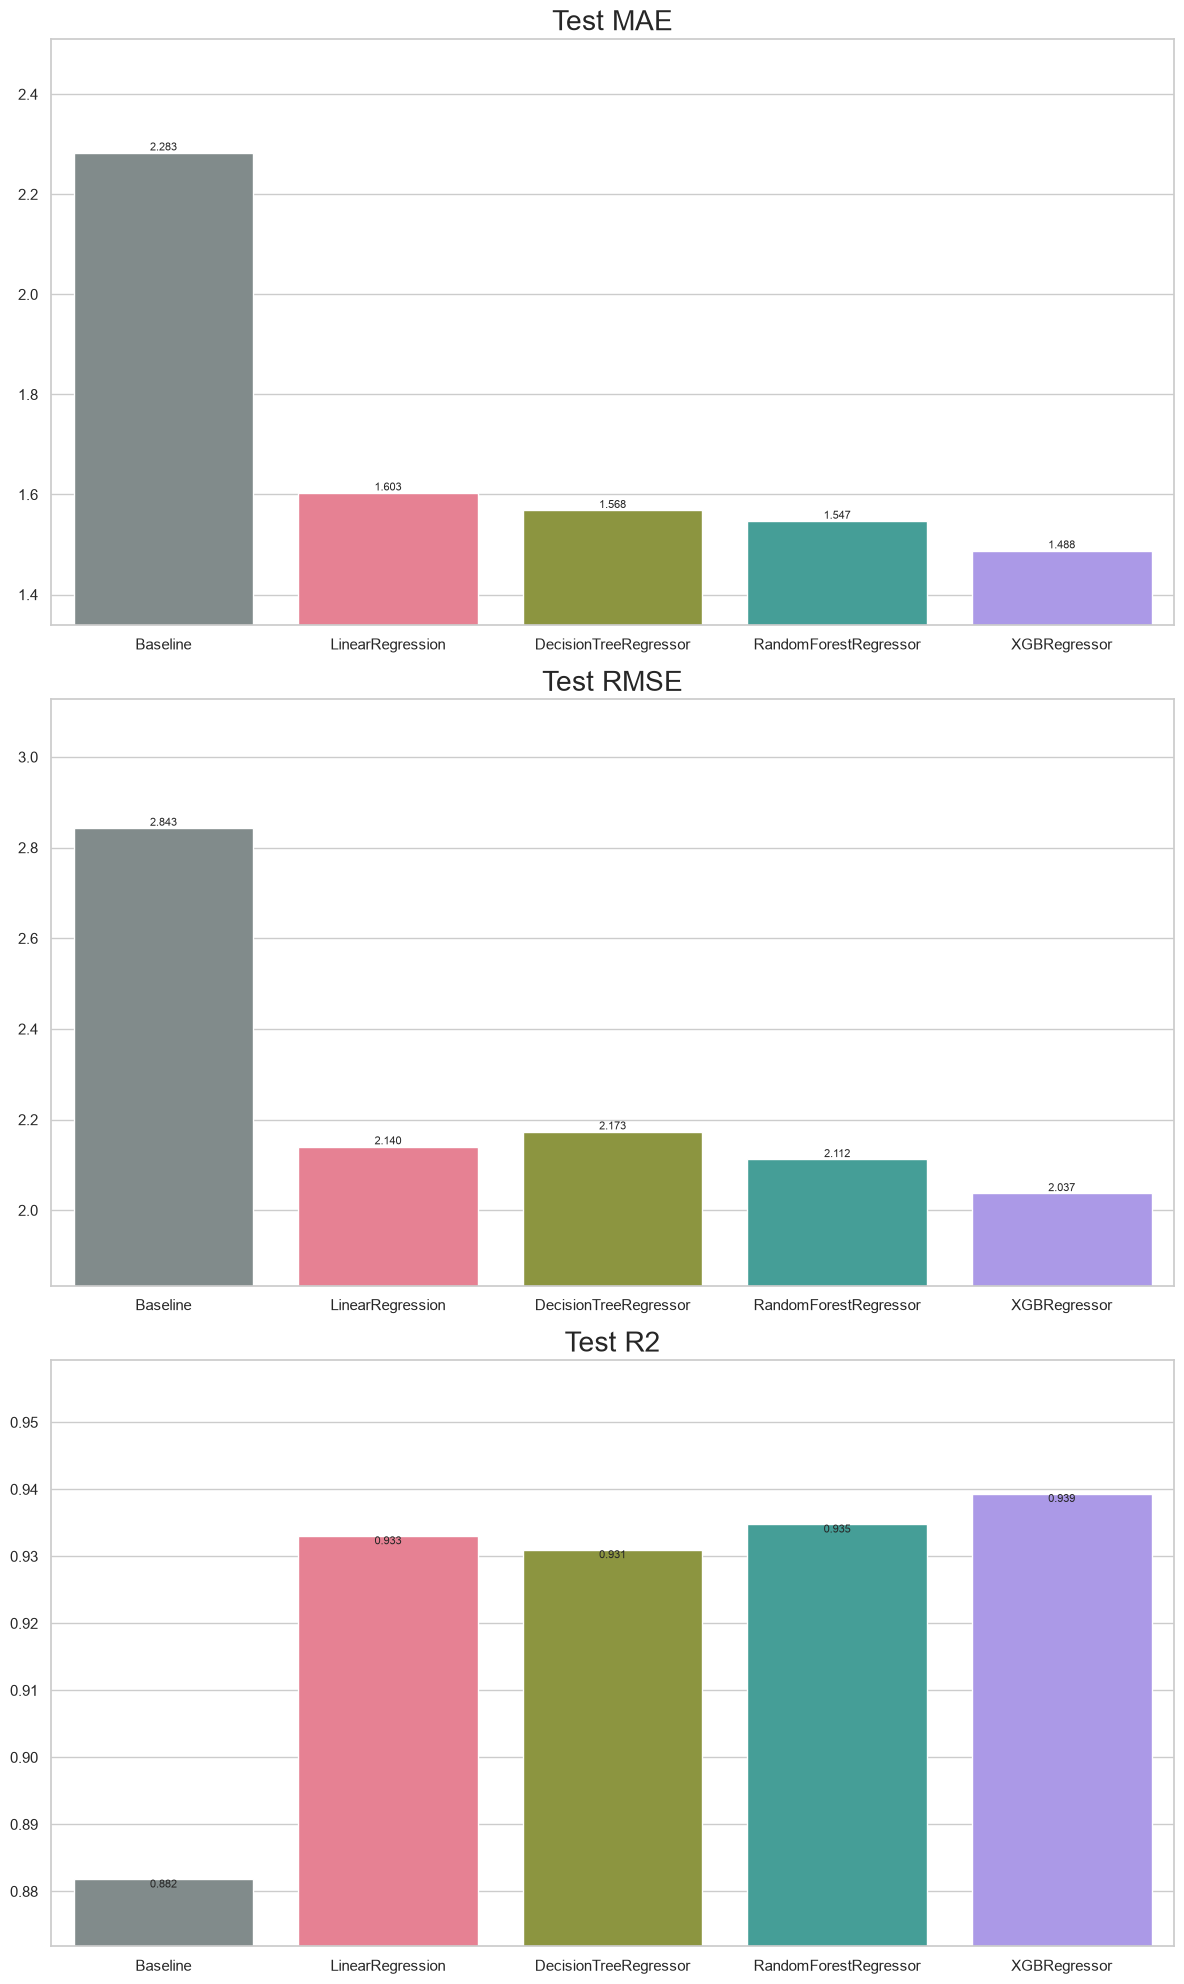

In [7]:
y_true = np.asarray(summary["targets"])
metric_names = ["MAE", "RMSE", "R2"]

b_met = EV.evaluate(y_true, np.asarray(summary["baseline"], dtype=float))
names = ["Baseline"] + model_names
colors = ["#7f8c8d"] + [color_by_name[n] for n in model_names]

fig, axes = plt.subplots(3, 1, figsize=(12, 20))
for ax, metric in zip(axes, metric_names):
    values = [b_met[metric]] + [summary["models"][n]["metrics"]["test"][metric] for n in model_names]
    sns.barplot(x=names, y=values, hue=names, palette=colors, ax=ax, legend=False)
    ax.set_title(f"Test {metric}", fontsize=20)
    for i, v in enumerate(values):
        va = "bottom" if metric != "R2" else "top"
        ax.text(i, v, f"{v:.3f}", ha="center", va=va, fontsize=8)
    if metric == "R2":
        ax.set_ylim(min(values) - 0.01, max(values) + 0.02)
    else:
        ax.set_ylim(min(values) * 0.9, max(values) * 1.1)
    ax.set_xlabel("",  rotation=45)
fig.tight_layout()
plt.show()

### Actual vs. Predicted Risk Scores (test) per model

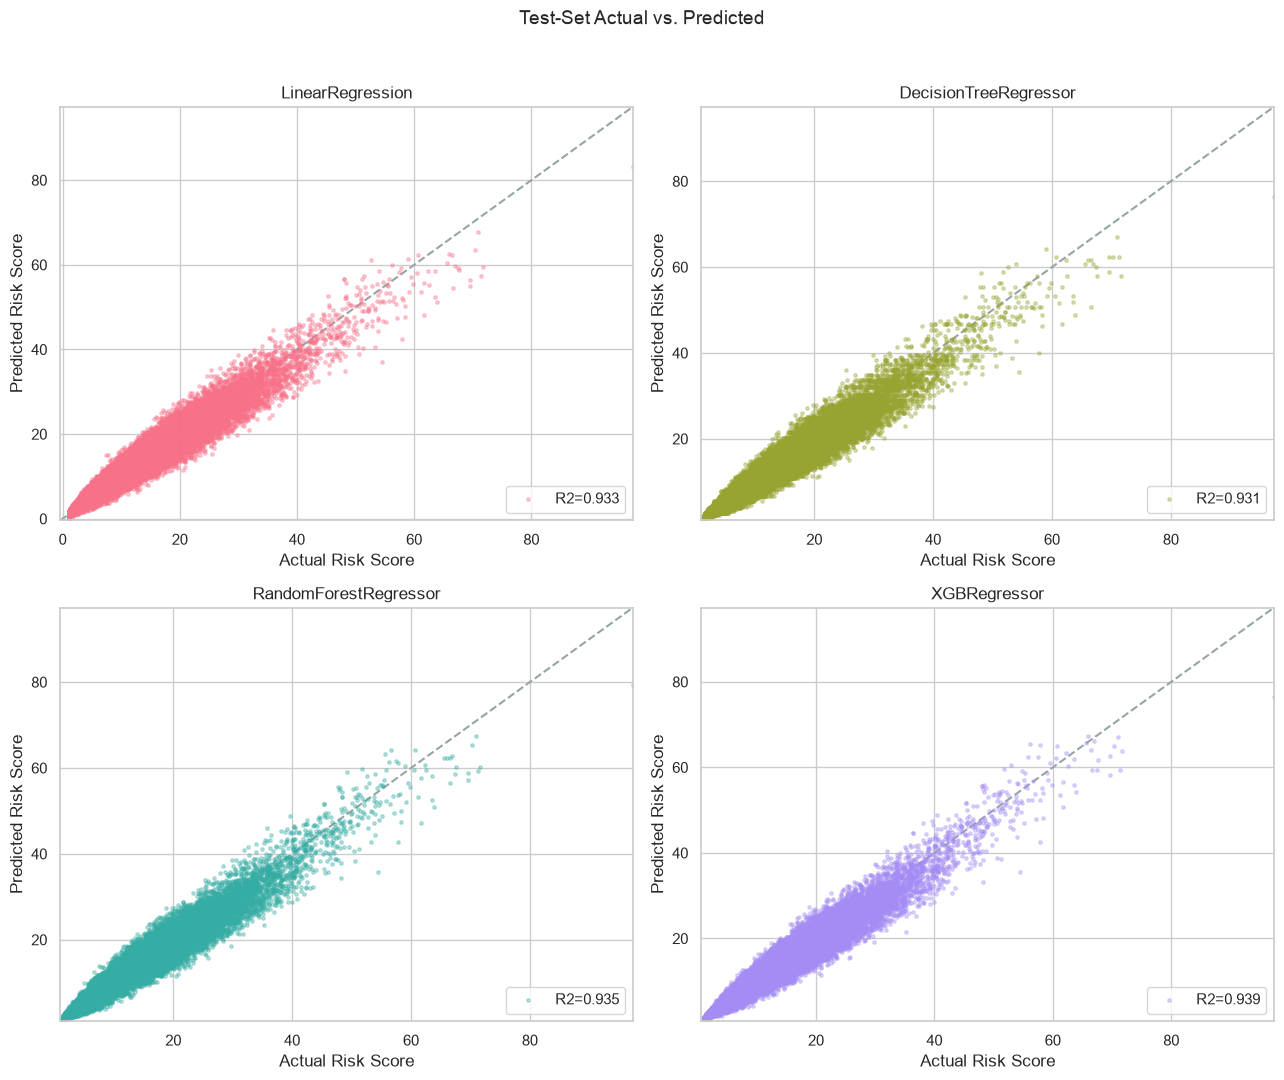

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, name in zip(axes.ravel(), model_names):
    y_pred = np.asarray(summary["models"][name]["predictions"])
    lims = (min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max()))
    ax.plot(lims, lims, ls="--", color="#95a5a6", zorder=1)
    ax.scatter(y_true, y_pred, s=6, alpha=0.35, color=color_by_name[name],
               label=f"R2={summary['models'][name]['metrics']['test']['R2']:.3f}" )
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual Risk Score"); ax.set_ylabel("Predicted Risk Score")
    ax.set_title(name)
    ax.legend(loc="lower right")
fig.suptitle("Test-Set Actual vs. Predicted", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Feature importance per model

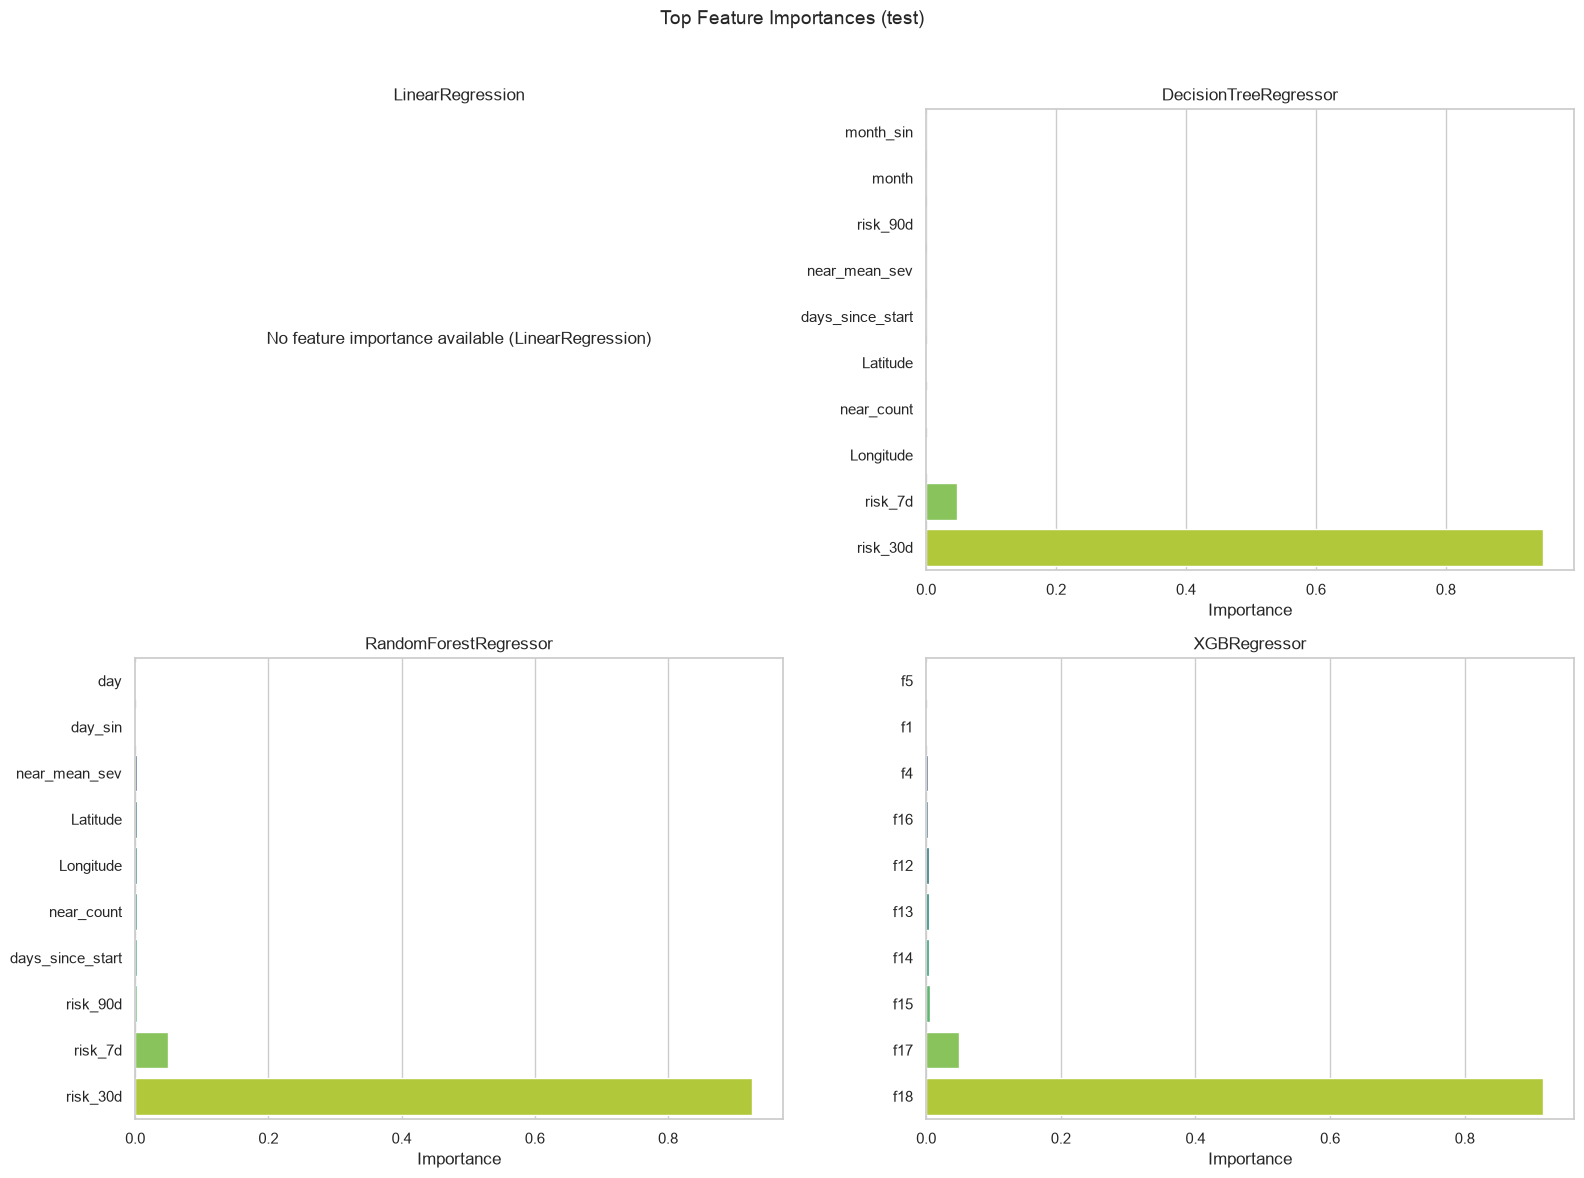

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, name in zip(axes.ravel(), model_names):
    imp = summary["models"][name]["feature_importance"]
    if not imp:
        ax.text(0.5, 0.5, "No feature importance available (LinearRegression)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(name)
        ax.set_axis_off()
        continue
    items = sorted(imp.items(), key=lambda kv: kv[1])[-10:]
    feats, vals = zip(*items)
    sns.barplot(x=list(vals), y=list(feats), hue=list(feats), palette="viridis", ax=ax, legend=False)
    ax.set_title(name)
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
fig.suptitle("Top Feature Importances (test)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()